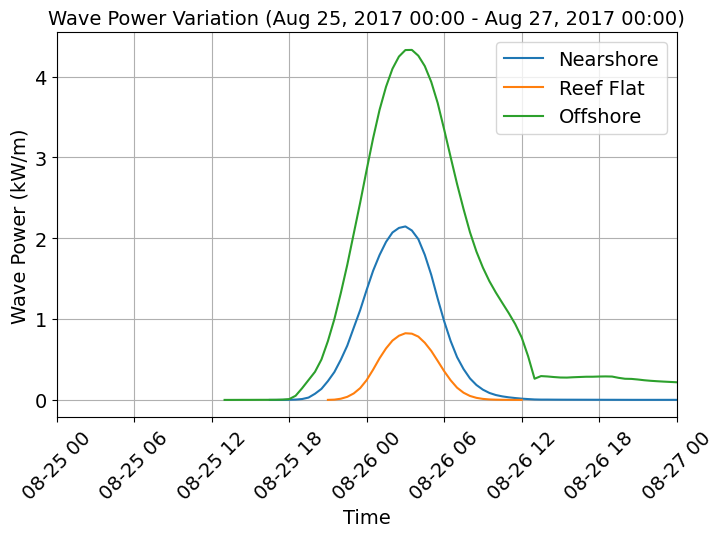

In [14]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# File path
dfsu_path = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey_with_reef_barrier_reef_Pattern.sw - Result Files\small_scale_wave_result_with_barrier_reef.dfsu"

# Load DFSU file
ds = mikeio.Dfsu(dfsu_path)

# Define target points (x, y coordinates)
target_coords = {
    "Nearshore": (732433, 3178648),
    "Reef Flat": (732663, 3177751),
    "Offshore": (732976, 3176646)
}

# Extract element center coordinates (ignore z)
elem_coords = np.array(ds.geometry.element_coordinates)[:, :2]  # Keep only (x, y)

# Find nearest elements
nearest_elements = {}
for loc, (x, y) in target_coords.items():
    distances = np.linalg.norm(elem_coords - np.array([x, y]), axis=1)  # ✅ Fixed broadcasting issue
    nearest_elements[loc] = np.argmin(distances)

# Read wave power data
wave_power_data = ds.read(items=["Wave power, p"])

# Extract time steps
time = np.array(ds.time)  # datetime timestamps

# Define time range for filtering (2017-08-25 00:00 to 2017-08-27 00:00)
start_time = np.datetime64("2017-08-25T00:00")
end_time = np.datetime64("2017-08-27T00:00")

# Find indices within time range
time_indices = np.where((time >= start_time) & (time <= end_time))[0]

# Extract wave power time series for each location within time range
wave_power_series = {loc: wave_power_data[0].values[time_indices, idx] for loc, idx in nearest_elements.items()}

# Plot wave power vs. time
plt.figure(figsize=(8, 5))
for loc, power_series in wave_power_series.items():
    plt.plot(time[time_indices], power_series, label=loc)

plt.xlabel("Time")
plt.ylabel("Wave Power (kW/m)")
plt.title("Wave Power Variation (Aug 25, 2017 00:00 - Aug 27, 2017 00:00)")
plt.legend()
plt.xticks(rotation=45)
plt.xlim(start_time, end_time)  # Show only the selected time range
plt.grid()
plt.show()



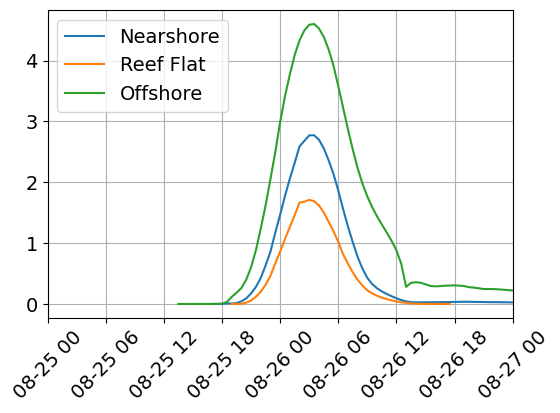

In [5]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# File path
dfsu_path = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Northside_barrier_reef_1.5m_v3.sw - Result Files\Northside_barrier_reef_1.5m_v3.dfsu"

# Load DFSU file
ds = mikeio.Dfsu(dfsu_path)

# Define target points (x, y coordinates)
target_coords = {
    "Nearshore": (732244, 3178728),
    "Reef Flat": (732448, 3178266),
    "Offshore": (732650, 3177820)
}

# Extract element center coordinates (ignore z)
elem_coords = np.array(ds.geometry.element_coordinates)[:, :2]

# Find nearest elements
nearest_elements = {}
for loc, (x, y) in target_coords.items():
    distances = np.linalg.norm(elem_coords - np.array([x, y]), axis=1)
    nearest_elements[loc] = np.argmin(distances)

# Read wave power data
wave_power_data = ds.read(items=["Wave power, p"])

# Extract time steps
time = np.array(ds.time)

# Define time range for filtering
start_time = np.datetime64("2017-08-25T00:00")
end_time = np.datetime64("2017-08-27T00:00")

# Find indices within time range
time_indices = np.where((time >= start_time) & (time <= end_time))[0]

# Extract wave power time series
wave_power_series = {
    loc: wave_power_data[0].values[time_indices, idx]
    for loc, idx in nearest_elements.items()
}

# =========================
# Plot
# =========================

tick_size = 14

plt.figure(figsize=(6, 4))

for loc, power_series in wave_power_series.items():
    plt.plot(time[time_indices], power_series, label=loc)

# plt.xlabel("Time")
# plt.ylabel("Wave Power (kW/m)")
# plt.title("Wave Power Variation (Aug 25, 2017 00:00 - Aug 27, 2017 00:00)")

plt.legend()
plt.xticks(rotation=45)
plt.xlim(start_time, end_time)

# Increase x and y tick label size
plt.tick_params(axis='both', labelsize=tick_size)

plt.grid()
plt.show()

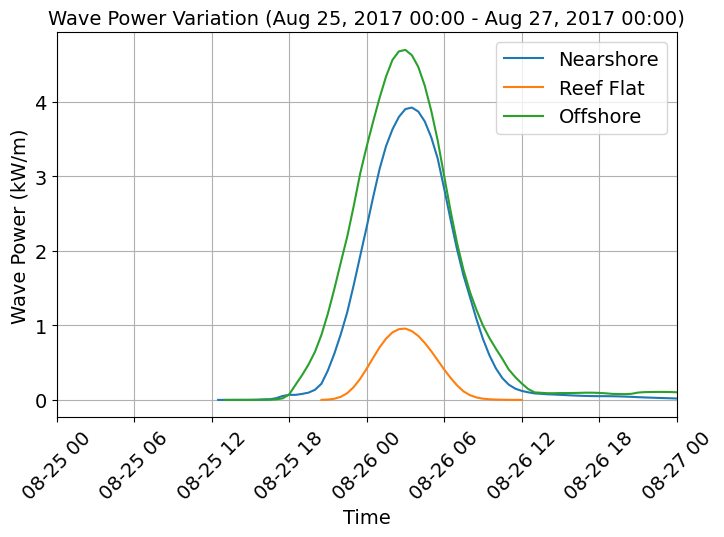

In [10]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# File path
dfsu_path = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef.sw - Result Files\small_scale_wave_result_with_barrier_reef.dfsu"

# Load DFSU file
ds = mikeio.Dfsu(dfsu_path)

# Define target points (x, y coordinates)
target_coords = {
    "Nearshore": (730277, 3175096),
    "Reef Flat": (731037, 3175492),
    "Offshore": (731545, 3175823)
}

# Extract element center coordinates (ignore z)
elem_coords = np.array(ds.geometry.element_coordinates)[:, :2]  # Keep only (x, y)

# Find nearest elements
nearest_elements = {}
for loc, (x, y) in target_coords.items():
    distances = np.linalg.norm(elem_coords - np.array([x, y]), axis=1)  # ✅ Fixed broadcasting issue
    nearest_elements[loc] = np.argmin(distances)

# Read wave power data
wave_power_data = ds.read(items=["Wave power, p"])

# Extract time steps
time = np.array(ds.time)  # datetime timestamps

# Define time range for filtering (2017-08-25 00:00 to 2017-08-27 00:00)
start_time = np.datetime64("2017-08-25T00:00")
end_time = np.datetime64("2017-08-27T00:00")

# Find indices within time range
time_indices = np.where((time >= start_time) & (time <= end_time))[0]

# Extract wave power time series for each location within time range
wave_power_series = {loc: wave_power_data[0].values[time_indices, idx] for loc, idx in nearest_elements.items()}
# Increase all default font sizes
plt.rcParams.update({
    'font.size': 14,         # base font size for text
    'axes.titlesize': 14,    # title
    'axes.labelsize': 14,    # x/y labels
    'xtick.labelsize': 14,   # x tick labels
    'ytick.labelsize': 14,   # y tick labels
    'legend.fontsize': 14    # legend
})
# Plot wave power vs. time
plt.figure(figsize=(8, 5))
for loc, power_series in wave_power_series.items():
    plt.plot(time[time_indices], power_series, label=loc)

plt.xlabel("Time")
plt.ylabel("Wave Power (kW/m)")
plt.title("Wave Power Variation (Aug 25, 2017 00:00 - Aug 27, 2017 00:00)")
plt.legend()
plt.xticks(rotation=45)
plt.xlim(start_time, end_time)  # Show only the selected time range
plt.grid()
plt.show()



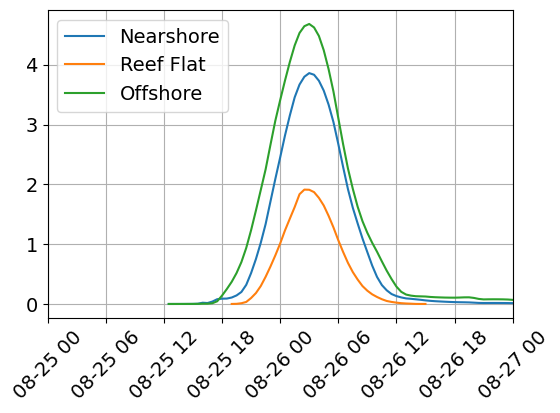

In [4]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# File path
dfsu_path = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_v2.sw - Result Files\west_side_barrier_reef_1.5m_v2.dfsu"

# Load DFSU file
ds = mikeio.Dfsu(dfsu_path)

# Define target points (x, y coordinates)
target_coords = {
    "Nearshore": (730601, 3174580),
    "Reef Flat": (730961, 3174951),
    "Offshore": (731316, 3175304)
}

# Extract element center coordinates (ignore z)
elem_coords = np.array(ds.geometry.element_coordinates)[:, :2]  # Keep only (x, y)

# Find nearest elements
nearest_elements = {}
for loc, (x, y) in target_coords.items():
    distances = np.linalg.norm(elem_coords - np.array([x, y]), axis=1)  # ✅ Fixed broadcasting issue
    nearest_elements[loc] = np.argmin(distances)

# Read wave power data
wave_power_data = ds.read(items=["Wave power, p"])

# Extract time steps
time = np.array(ds.time)  # datetime timestamps

# Define time range for filtering (2017-08-25 00:00 to 2017-08-27 00:00)
start_time = np.datetime64("2017-08-25T00:00")
end_time = np.datetime64("2017-08-27T00:00")

# Find indices within time range
time_indices = np.where((time >= start_time) & (time <= end_time))[0]

# Extract wave power time series for each location within time range
wave_power_series = {loc: wave_power_data[0].values[time_indices, idx] for loc, idx in nearest_elements.items()}
# Increase all default font sizes
plt.rcParams.update({
    'font.size': 14,         # base font size for text
    'axes.titlesize': 14,    # title
    'axes.labelsize': 14,    # x/y labels
    'xtick.labelsize': 14,   # x tick labels
    'ytick.labelsize': 14,   # y tick labels
    'legend.fontsize': 14    # legend
})
# Plot wave power vs. time
plt.figure(figsize=(6, 4))
for loc, power_series in wave_power_series.items():
    plt.plot(time[time_indices], power_series, label=loc)

# plt.xlabel("Time")
# plt.ylabel("Wave Power (kW/m)")
# plt.title("Wave Power Variation (Aug 25, 2017 00:00 - Aug 27, 2017 00:00)")
plt.legend()
plt.xticks(rotation=45)
plt.xlim(start_time, end_time)  # Show only the selected time range
plt.grid()
plt.show()



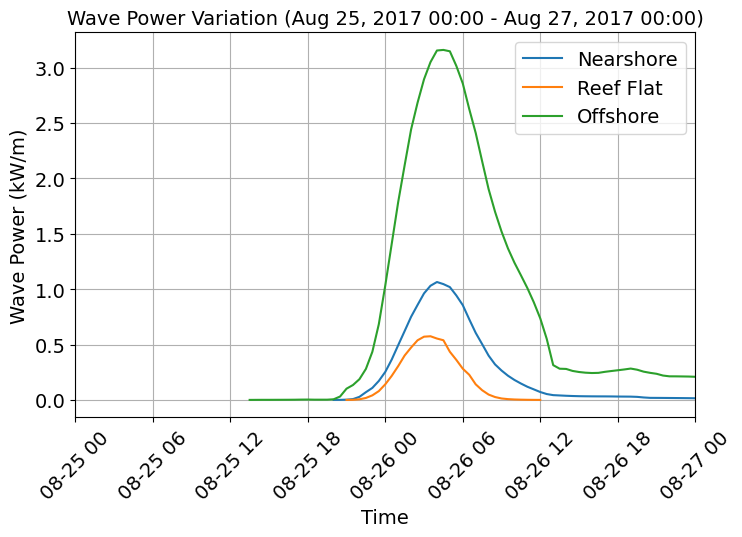

In [13]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# File path
dfsu_path = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_side_barrier_reef.sw - Result Files\east_side_reef.dfsu"

# Load DFSU file
ds = mikeio.Dfsu(dfsu_path)

# Define target points (x, y coordinates)
target_coords = {
    "Nearshore": (736253, 3177009),
    "Reef Flat": (735677, 3176740),
    "Offshore": (735251, 3176462)
}

# Extract element center coordinates (ignore z)
elem_coords = np.array(ds.geometry.element_coordinates)[:, :2]  # Keep only (x, y)

# Find nearest elements
nearest_elements = {}
for loc, (x, y) in target_coords.items():
    distances = np.linalg.norm(elem_coords - np.array([x, y]), axis=1)  # ✅ Fixed broadcasting issue
    nearest_elements[loc] = np.argmin(distances)

# Read wave power data
wave_power_data = ds.read(items=["Wave power, p"])

# Extract time steps
time = np.array(ds.time)  # datetime timestamps

# Define time range for filtering (2017-08-25 00:00 to 2017-08-27 00:00)
start_time = np.datetime64("2017-08-25T00:00")
end_time = np.datetime64("2017-08-27T00:00")

# Find indices within time range
time_indices = np.where((time >= start_time) & (time <= end_time))[0]

# Extract wave power time series for each location within time range
wave_power_series = {loc: wave_power_data[0].values[time_indices, idx] for loc, idx in nearest_elements.items()}
# Increase all default font sizes
plt.rcParams.update({
    'font.size': 14,         # base font size for text
    'axes.titlesize': 14,    # title
    'axes.labelsize': 14,    # x/y labels
    'xtick.labelsize': 14,   # x tick labels
    'ytick.labelsize': 14,   # y tick labels
    'legend.fontsize': 14    # legend
})

# Plot wave power vs. time
plt.figure(figsize=(8, 5))
for loc, power_series in wave_power_series.items():
    plt.plot(time[time_indices], power_series, label=loc)

plt.xlabel("Time")
plt.ylabel("Wave Power (kW/m)")
plt.title("Wave Power Variation (Aug 25, 2017 00:00 - Aug 27, 2017 00:00)")
plt.legend()
plt.xticks(rotation=45)
plt.xlim(start_time, end_time)  # Show only the selected time range
plt.grid()
plt.show()



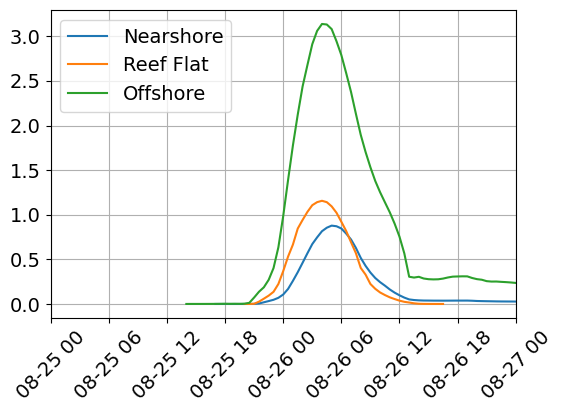

In [7]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# File path
dfsu_path = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_side_barrier_reef_1.5m_v2.sw - Result Files\east_side_reef_1.5m_v2.dfsu"

# Load DFSU file
ds = mikeio.Dfsu(dfsu_path)

# Define target points (x, y coordinates)
target_coords = {
    "Nearshore": (736397, 3177672),
    "Reef Flat": (735938, 3177515),
    "Offshore": (735481, 3177360)
}

# Extract element center coordinates (ignore z)
elem_coords = np.array(ds.geometry.element_coordinates)[:, :2]  # Keep only (x, y)

# Find nearest elements
nearest_elements = {}
for loc, (x, y) in target_coords.items():
    distances = np.linalg.norm(elem_coords - np.array([x, y]), axis=1)  # ✅ Fixed broadcasting issue
    nearest_elements[loc] = np.argmin(distances)

# Read wave power data
wave_power_data = ds.read(items=["Wave power, p"])

# Extract time steps
time = np.array(ds.time)  # datetime timestamps

# Define time range for filtering (2017-08-25 00:00 to 2017-08-27 00:00)
start_time = np.datetime64("2017-08-25T00:00")
end_time = np.datetime64("2017-08-27T00:00")

# Find indices within time range
time_indices = np.where((time >= start_time) & (time <= end_time))[0]

# Extract wave power time series for each location within time range
wave_power_series = {loc: wave_power_data[0].values[time_indices, idx] for loc, idx in nearest_elements.items()}
# Increase all default font sizes
plt.rcParams.update({
    'font.size': 14,         # base font size for text
    'axes.titlesize': 14,    # title
    'axes.labelsize': 14,    # x/y labels
    'xtick.labelsize': 14,   # x tick labels
    'ytick.labelsize': 14,   # y tick labels
    'legend.fontsize': 14    # legend
})

# Plot wave power vs. time
plt.figure(figsize=(6, 4))
for loc, power_series in wave_power_series.items():
    plt.plot(time[time_indices], power_series, label=loc)

# plt.xlabel("Time")
# plt.ylabel("Wave Power (kW/m)")
# plt.title("Wave Power Variation (Aug 25, 2017 00:00 - Aug 27, 2017 00:00)")
plt.legend()
plt.xticks(rotation=45)
plt.xlim(start_time, end_time)  # Show only the selected time range
plt.grid()
plt.show()



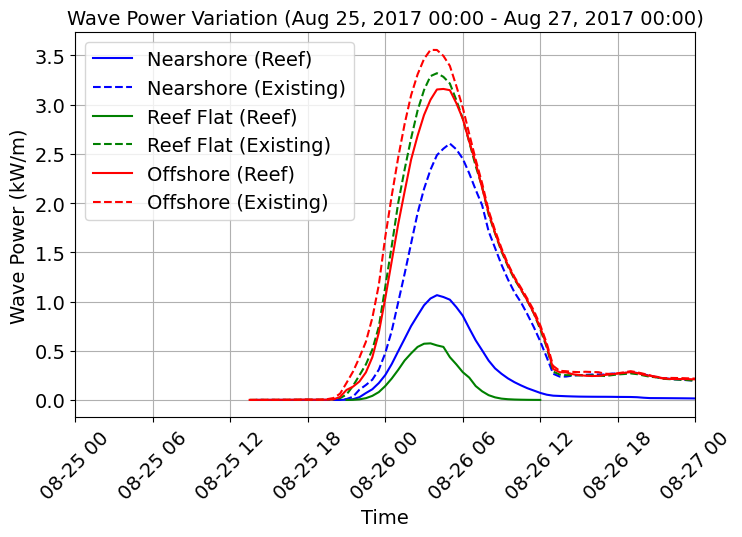

In [12]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# File paths
existing_file = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"
east_reef_file = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_side_barrier_reef.sw - Result Files\east_side_reef.dfsu"

# Define target points (x, y coordinates)
target_coords = {
    "Nearshore": (736253, 3177009),
    "Reef Flat": (735677, 3176740),
    "Offshore": (735251, 3176462)
}

def extract_wave_power(file_path, target_coords):
    """Extracts wave power time series for given coordinates from a DFSU file."""
    ds = mikeio.Dfsu(file_path)

    # Extract element center coordinates (ignore z)
    elem_coords = np.array(ds.geometry.element_coordinates)[:, :2]

    # Find nearest elements
    nearest_elements = {}
    for loc, (x, y) in target_coords.items():
        distances = np.linalg.norm(elem_coords - np.array([x, y]), axis=1)
        nearest_elements[loc] = np.argmin(distances)

    # Read wave power data
    wave_power_data = ds.read(items=["Wave power, p"])[0].values

    # Extract time steps
    time = np.array(ds.time)

    return time, {loc: wave_power_data[:, idx] for loc, idx in nearest_elements.items()}

# Extract data from both files
time_existing, wave_power_existing = extract_wave_power(existing_file, target_coords)
time_reef, wave_power_reef = extract_wave_power(east_reef_file, target_coords)

# Define time range for filtering (2017-08-25 00:00 to 2017-08-27 00:00)
start_time = np.datetime64("2017-08-25T00:00")
end_time = np.datetime64("2017-08-27T00:00")

# Find indices within time range
time_indices_existing = np.where((time_existing >= start_time) & (time_existing <= end_time))[0]
time_indices_reef = np.where((time_reef >= start_time) & (time_reef <= end_time))[0]
# Increase all default font sizes
plt.rcParams.update({
    'font.size': 14,         # base font size for text
    'axes.titlesize': 14,    # title
    'axes.labelsize': 14,    # x/y labels
    'xtick.labelsize': 14,   # x tick labels
    'ytick.labelsize': 14,   # y tick labels
    'legend.fontsize': 14    # legend
})
# Plot wave power vs. time for both cases
plt.figure(figsize=(8, 5))

colors = {"Nearshore": "blue", "Reef Flat": "green", "Offshore": "red"}

for loc in target_coords.keys():
    plt.plot(time_reef[time_indices_reef], 
             wave_power_reef[loc][time_indices_reef], 
             label=f"{loc} (Reef)", color=colors[loc], linestyle='-')
    
    plt.plot(time_existing[time_indices_existing], 
             wave_power_existing[loc][time_indices_existing], 
             label=f"{loc} (Existing)", color=colors[loc], linestyle='--')

plt.xlabel("Time")
plt.ylabel("Wave Power (kW/m)")
plt.title("Wave Power Variation (Aug 25, 2017 00:00 - Aug 27, 2017 00:00)")
plt.legend()
plt.xticks(rotation=45)
plt.xlim(start_time, end_time)
plt.grid()
plt.show()


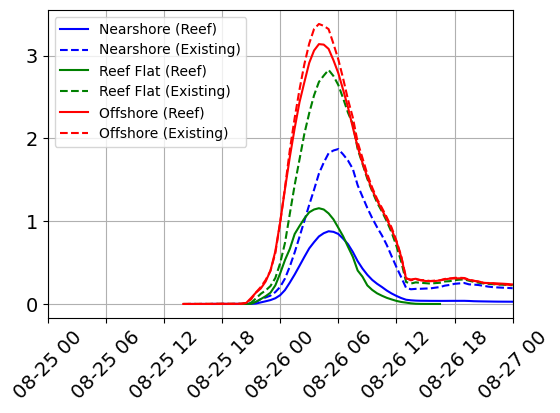

In [12]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# File paths
existing_file = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"
east_reef_file = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_side_barrier_reef_1.5m_v2.sw - Result Files\east_side_reef_1.5m_v2.dfsu"

# Define target points (x, y coordinates)
target_coords = {
    "Nearshore": (736397, 3177672),
    "Reef Flat": (735938, 3177515),
    "Offshore": (735481, 3177360)
}

def extract_wave_power(file_path, target_coords):
    """Extracts wave power time series for given coordinates from a DFSU file."""
    ds = mikeio.Dfsu(file_path)

    # Extract element center coordinates (ignore z)
    elem_coords = np.array(ds.geometry.element_coordinates)[:, :2]

    # Find nearest elements
    nearest_elements = {}
    for loc, (x, y) in target_coords.items():
        distances = np.linalg.norm(elem_coords - np.array([x, y]), axis=1)
        nearest_elements[loc] = np.argmin(distances)

    # Read wave power data
    wave_power_data = ds.read(items=["Wave power, p"])[0].values

    # Extract time steps
    time = np.array(ds.time)

    return time, {loc: wave_power_data[:, idx] for loc, idx in nearest_elements.items()}

# Extract data from both files
time_existing, wave_power_existing = extract_wave_power(existing_file, target_coords)
time_reef, wave_power_reef = extract_wave_power(east_reef_file, target_coords)

# Define time range for filtering (2017-08-25 00:00 to 2017-08-27 00:00)
start_time = np.datetime64("2017-08-25T00:00")
end_time = np.datetime64("2017-08-27T00:00")

# Find indices within time range
time_indices_existing = np.where((time_existing >= start_time) & (time_existing <= end_time))[0]
time_indices_reef = np.where((time_reef >= start_time) & (time_reef <= end_time))[0]
# Increase all default font sizes
plt.rcParams.update({
    'font.size': 14,         # base font size for text
    'axes.titlesize': 14,    # title
    'axes.labelsize': 14,    # x/y labels
    'xtick.labelsize': 14,   # x tick labels
    'ytick.labelsize': 14,   # y tick labels
    'legend.fontsize': 10    # legend
})
# Plot wave power vs. time for both cases
plt.figure(figsize=(6, 4))

colors = {"Nearshore": "blue", "Reef Flat": "green", "Offshore": "red"}

for loc in target_coords.keys():
    plt.plot(time_reef[time_indices_reef], 
             wave_power_reef[loc][time_indices_reef], 
             label=f"{loc} (Reef)", color=colors[loc], linestyle='-')
    
    plt.plot(time_existing[time_indices_existing], 
             wave_power_existing[loc][time_indices_existing], 
             label=f"{loc} (Existing)", color=colors[loc], linestyle='--')

# plt.xlabel("Time")
# plt.ylabel("Wave Power (kW/m)")
# plt.title("Wave Power Variation (Aug 25, 2017 00:00 - Aug 27, 2017 00:00)")
plt.legend()
plt.xticks(rotation=45)
plt.xlim(start_time, end_time)
plt.grid()
plt.show()


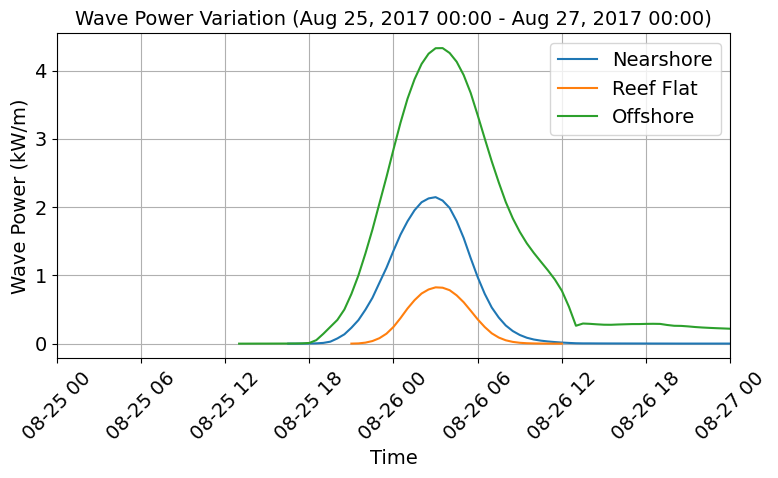

In [11]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# File path
dfsu_path = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey_with_reef_barrier_reef_Pattern.sw - Result Files\small_scale_wave_result_with_barrier_reef.dfsu"

# Load DFSU file
ds = mikeio.Dfsu(dfsu_path)

# Define target points (x, y coordinates)
target_coords = {
    "Nearshore": (732433, 3178648),
    "Reef Flat": (732663, 3177751),
    "Offshore": (732976, 3176646)
}

# Extract element center coordinates (ignore z)
elem_coords = np.array(ds.geometry.element_coordinates)[:, :2]

# Find nearest elements
nearest_elements = {}
for loc, (x, y) in target_coords.items():
    distances = np.linalg.norm(elem_coords - np.array([x, y]), axis=1)
    nearest_elements[loc] = np.argmin(distances)

# Read wave power data
wave_power_data = ds.read(items=["Wave power, p"])

# Extract time steps
time = np.array(ds.time)

# Define time range for filtering
start_time = np.datetime64("2017-08-25T00:00")
end_time   = np.datetime64("2017-08-27T00:00")
time_indices = np.where((time >= start_time) & (time <= end_time))[0]

# Extract wave power time series
wave_power_series = {
    loc: wave_power_data[0].values[time_indices, idx]
    for loc, idx in nearest_elements.items()
}

# Increase all default font sizes
plt.rcParams.update({
    'font.size': 14,         # base font size for text
    'axes.titlesize': 14,    # title
    'axes.labelsize': 14,    # x/y labels
    'xtick.labelsize': 14,   # x tick labels
    'ytick.labelsize': 14,   # y tick labels
    'legend.fontsize': 14    # legend
})

# Plot
plt.figure(figsize=(8, 5))
for loc, power_series in wave_power_series.items():
    plt.plot(time[time_indices], power_series, label=loc)

plt.xlabel("Time")
plt.ylabel("Wave Power (kW/m)")
plt.title("Wave Power Variation (Aug 25, 2017 00:00 - Aug 27, 2017 00:00)")
plt.legend(loc="best")
plt.xticks(rotation=45)
plt.xlim(start_time, end_time)
plt.grid(True)
plt.tight_layout()
plt.show()


Nearest element IDs:
Reef Flat: 24818
Offshore: 5732


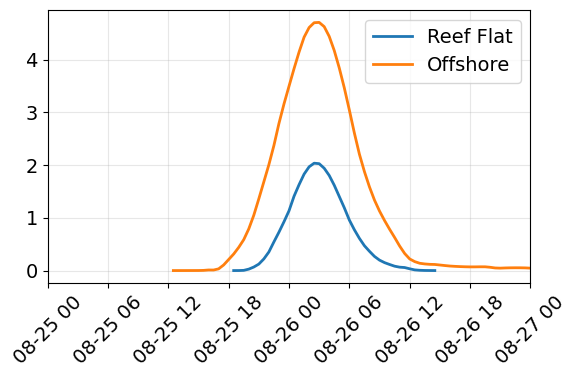

In [13]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File path: West-side fringing reef
# =========================
dfsu_path = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_fringing_reef_v1.sw - Result Files\west_side_fringing_reef_1.5m_v2.dfsu"

# Load DFSU file
ds = mikeio.Dfsu(dfsu_path)

# =========================
# Define target points
# Omitting nearshore point
# =========================
target_coords = {
    "Reef Flat": (730621, 3174581),
    "Offshore": (730971, 3174938)
}

# =========================
# Find nearest elements
# =========================
elem_coords = np.array(ds.geometry.element_coordinates)[:, :2]

nearest_elements = {}

for loc, (x, y) in target_coords.items():
    distances = np.linalg.norm(elem_coords - np.array([x, y]), axis=1)
    nearest_elements[loc] = np.argmin(distances)

print("Nearest element IDs:")
for loc, idx in nearest_elements.items():
    print(f"{loc}: {idx}")

# =========================
# Read wave power data
# =========================
wave_power_data = ds.read(items=["Wave power, p"])

# Extract time steps
time = np.array(ds.time)

# =========================
# Define time range
# =========================
start_time = np.datetime64("2017-08-25T00:00")
end_time = np.datetime64("2017-08-27T00:00")

time_indices = np.where((time >= start_time) & (time <= end_time))[0]

# =========================
# Extract wave power time series
# =========================
wave_power_series = {
    loc: wave_power_data[0].values[time_indices, idx]
    for loc, idx in nearest_elements.items()
}

# =========================
# Plot settings
# =========================
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

# =========================
# Plot wave power vs time
# =========================
plt.figure(figsize=(6, 4))

for loc, power_series in wave_power_series.items():
    plt.plot(
        time[time_indices],
        power_series,
        linewidth=2,
        label=loc
    )

plt.legend()
plt.xticks(rotation=45)
plt.xlim(start_time, end_time)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Processing North Side...
Processing West Side...
Processing East Side...

Maximum wave power values:
 Reef_Side  Location  Maximum_Wave_Power     Time_of_Maximum
North Side Nearshore            2.774697 2017-08-26 03:30:00
North Side Reef Flat            1.711006 2017-08-26 03:00:00
North Side  Offshore            4.602911 2017-08-26 03:30:00
 West Side Nearshore            3.859551 2017-08-26 03:00:00
 West Side Reef Flat            1.912099 2017-08-26 02:30:00
 West Side  Offshore            4.681147 2017-08-26 03:00:00
 East Side Nearshore            0.878273 2017-08-26 05:00:00
 East Side Reef Flat            1.156630 2017-08-26 04:00:00
 East Side  Offshore            3.138534 2017-08-26 04:00:00

Excel output saved successfully:
D:\Phd Research\Wave Model\small scale port lavaca\Simulation\wave_power_maximum_comparison.xlsx


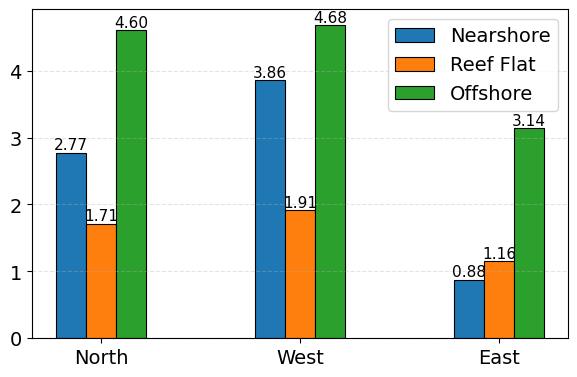

In [22]:
import mikeio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==========================================================
# Input DFSU files and target coordinates
# ==========================================================

reef_cases = {
    "North Side": {
        "file": (
            r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
            r"\Northside_barrier_reef_1.5m_v3.sw - Result Files"
            r"\Northside_barrier_reef_1.5m_v3.dfsu"
        ),
        "points": {
            "Nearshore": (732244, 3178728),
            "Reef Flat": (732448, 3178266),
            "Offshore": (732650, 3177820),
        },
    },

    "West Side": {
        "file": (
            r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
            r"\West_side_barrier_reef_1.5m_v2.sw - Result Files"
            r"\west_side_barrier_reef_1.5m_v2.dfsu"
        ),
        "points": {
            "Nearshore": (730601, 3174580),
            "Reef Flat": (730961, 3174951),
            "Offshore": (731316, 3175304),
        },
    },

    "East Side": {
        "file": (
            r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
            r"\east_side_barrier_reef_1.5m_v2.sw - Result Files"
            r"\east_side_reef_1.5m_v2.dfsu"
        ),
        "points": {
            "Nearshore": (736397, 3177672),
            "Reef Flat": (735938, 3177515),
            "Offshore": (735481, 3177360),
        },
    },
}

# ==========================================================
# Output paths
# ==========================================================

output_folder = Path(
    r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
)

excel_out = output_folder / "wave_power_maximum_comparison.xlsx"
figure_out = output_folder / "wave_power_maximum_grouped_bar_chart.png"

item_name = "Wave power, p"

# ==========================================================
# Function to extract time series at nearest mesh elements
# ==========================================================

def extract_wave_power_time_series(dfsu_path, target_points):
    """
    Extract Wave power, p time series at the nearest mesh element
    for each target coordinate.

    Returns
    -------
    df : pandas.DataFrame
        Time series dataframe.
    point_info : pandas.DataFrame
        Requested and actual nearest-element coordinates.
    """

    dfs = mikeio.open(dfsu_path)

    # Read only the requested item
    ds = dfs.read(items=[item_name])
    da = ds[0]

    # Element-center coordinates
    elem_coords = np.asarray(dfs.geometry.element_coordinates)[:, :2]

    # Time index
    time_index = pd.to_datetime(ds.time)

    df = pd.DataFrame(index=time_index)
    df.index.name = "Time"

    point_records = []

    for point_name, (x_target, y_target) in target_points.items():

        # Distance from target point to each mesh element center
        distances = np.sqrt(
            (elem_coords[:, 0] - x_target) ** 2
            + (elem_coords[:, 1] - y_target) ** 2
        )

        nearest_element = int(np.argmin(distances))

        x_actual = elem_coords[nearest_element, 0]
        y_actual = elem_coords[nearest_element, 1]
        nearest_distance = distances[nearest_element]

        # Extract all time steps at nearest element
        values = np.asarray(
            da.values[:, nearest_element],
            dtype=float
        )

        # Replace MIKE delete values/extreme invalid values with NaN
        values[np.abs(values) > 1.0e30] = np.nan

        df[point_name] = values

        point_records.append({
            "Point": point_name,
            "Requested_Easting_m": x_target,
            "Requested_Northing_m": y_target,
            "Nearest_Element_ID_Zero_Based": nearest_element,
            "Actual_Easting_m": x_actual,
            "Actual_Northing_m": y_actual,
            "Distance_to_Nearest_Element_m": nearest_distance,
        })

    point_info = pd.DataFrame(point_records)

    return df, point_info


# ==========================================================
# Extract time series and maximum values
# ==========================================================

time_series_results = {}
point_information = {}
summary_records = []

for side_name, case in reef_cases.items():

    print(f"Processing {side_name}...")

    df_ts, df_points = extract_wave_power_time_series(
        case["file"],
        case["points"]
    )

    time_series_results[side_name] = df_ts
    point_information[side_name] = df_points

    for point_name in case["points"].keys():

        series = df_ts[point_name]

        if series.notna().any():
            max_value = series.max(skipna=True)
            max_time = series.idxmax(skipna=True)
        else:
            max_value = np.nan
            max_time = pd.NaT

        summary_records.append({
            "Reef_Side": side_name,
            "Location": point_name,
            "Maximum_Wave_Power": max_value,
            "Time_of_Maximum": max_time,
        })

summary_df = pd.DataFrame(summary_records)

# ==========================================================
# Print maximum values
# ==========================================================

print("\nMaximum wave power values:")
print(summary_df.to_string(index=False))

# ==========================================================
# Export results to Excel
# ==========================================================

with pd.ExcelWriter(excel_out, engine="openpyxl") as writer:

    # Maximum-value summary
    summary_df.to_excel(
        writer,
        sheet_name="Maximum_Wave_Power",
        index=False
    )

    # Individual time-series and point-information sheets
    for side_name in reef_cases.keys():

        short_name = side_name.replace(" Side", "")

        time_series_results[side_name].to_excel(
            writer,
            sheet_name=f"{short_name}_Time_Series",
            index=True
        )

        point_information[side_name].to_excel(
            writer,
            sheet_name=f"{short_name}_Point_Info",
            index=False
        )

print("\nExcel output saved successfully:")
print(excel_out)

# ==========================================================
# Prepare grouped bar-chart data
# ==========================================================

site_order = [
    "North Side",
    "West Side",
    "East Side"
]

location_order = [
    "Nearshore",
    "Reef Flat",
    "Offshore"
]

nearshore_values = []
reef_flat_values = []
offshore_values = []

for site in site_order:

    site_data = (
        summary_df[
            summary_df["Reef_Side"] == site
        ]
        .set_index("Location")
    )

    nearshore_values.append(
        site_data.loc["Nearshore", "Maximum_Wave_Power"]
    )

    reef_flat_values.append(
        site_data.loc["Reef Flat", "Maximum_Wave_Power"]
    )

    offshore_values.append(
        site_data.loc["Offshore", "Maximum_Wave_Power"]
    )

# ==========================================================
# Single grouped bar chart
# ==========================================================

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

x = np.arange(len(site_order))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(6, 4))

bars_nearshore = ax.bar(
    x - bar_width,
    nearshore_values,
    width=bar_width,
    label="Nearshore",
    color="tab:blue",
    edgecolor="black",
    linewidth=0.8
)

bars_reef_flat = ax.bar(
    x,
    reef_flat_values,
    width=bar_width,
    label="Reef Flat",
    color="tab:orange",
    edgecolor="black",
    linewidth=0.8
)

bars_offshore = ax.bar(
    x + bar_width,
    offshore_values,
    width=bar_width,
    label="Offshore",
    color="tab:green",
    edgecolor="black",
    linewidth=0.8
)

# X-axis groups
ax.set_xticks(x)
ax.set_xticklabels([
    "North",
    "West",
    "East"
])

# ax.set_xlabel("Reef location")
# ax.set_ylabel("Maximum wave power, p")

# ax.set_title(
#     "Maximum Wave Power at Cross-Shore Locations"
# )

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

ax.legend(
    loc="best",
    frameon=True
)

# ==========================================================
# Add values above bars
# ==========================================================

def add_bar_labels(bars):

    for bar in bars:

        height = bar.get_height()

        if np.isfinite(height):

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{height:.2f}",
                ha="center",
                va="bottom",
                fontsize=11
            )

add_bar_labels(bars_nearshore)
add_bar_labels(bars_reef_flat)
add_bar_labels(bars_offshore)

plt.tight_layout()

# Save figure
plt.savefig(
    figure_out,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


Processing North side...
Processing West side...
Processing East side...

Excel file saved successfully:
D:\Phd Research\Wave Model\small scale port lavaca\Simulation\temporal_wave_power_reduction.xlsx


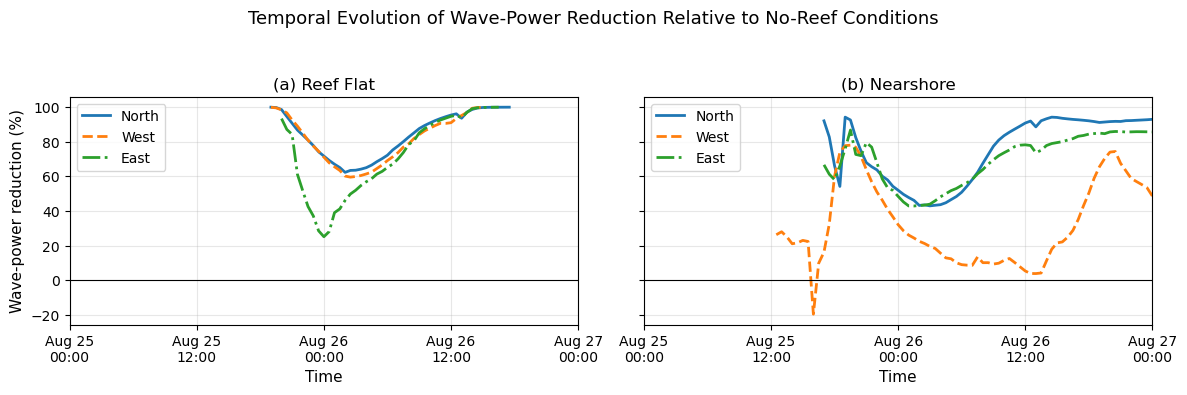

In [23]:
import mikeio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# ==========================================================
# File paths
# ==========================================================

dfsu_no_reef = (
    r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
    r"\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files"
    r"\small_scale_wave_result.dfsu"
)

reef_cases = {
    "North": {
        "file": (
            r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
            r"\Northside_barrier_reef_1.5m_v3.sw - Result Files"
            r"\Northside_barrier_reef_1.5m_v3.dfsu"
        ),
        "points": {
            "Nearshore": (732244, 3178728),
            "Reef Flat": (732448, 3178266),
        },
    },

    "West": {
        "file": (
            r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
            r"\West_side_barrier_reef_1.5m_v2.sw - Result Files"
            r"\west_side_barrier_reef_1.5m_v2.dfsu"
        ),
        "points": {
            "Nearshore": (730601, 3174580),
            "Reef Flat": (730961, 3174951),
        },
    },

    "East": {
        "file": (
            r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
            r"\east_side_barrier_reef_1.5m_v2.sw - Result Files"
            r"\east_side_reef_1.5m_v2.dfsu"
        ),
        "points": {
            "Nearshore": (736397, 3177672),
            "Reef Flat": (735938, 3177515),
        },
    },
}

# ==========================================================
# Output paths
# ==========================================================

output_folder = Path(
    r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
)

excel_out = output_folder / "temporal_wave_power_reduction.xlsx"
figure_out = output_folder / "temporal_wave_power_reduction.png"

item_name = "Wave power, p"

# Avoid division by values very close to zero
minimum_wave_power = 1.0e-8

# ==========================================================
# Time range
# ==========================================================

start_time = pd.Timestamp("2017-08-25 00:00:00")
end_time = pd.Timestamp("2017-08-27 00:00:00")

# ==========================================================
# Function: extract nearest-element time series
# ==========================================================

def extract_wave_power_at_points(dfsu_path, target_points):
    """
    Extract Wave power, p time series at the nearest mesh element
    for each requested coordinate.
    """

    dfs = mikeio.open(dfsu_path)
    ds = dfs.read(items=[item_name])
    da = ds[0]

    element_coords = np.asarray(
        dfs.geometry.element_coordinates
    )[:, :2]

    time_index = pd.to_datetime(ds.time)

    df = pd.DataFrame(index=time_index)
    df.index.name = "Time"

    point_records = []

    for point_name, (x_target, y_target) in target_points.items():

        distances = np.sqrt(
            (element_coords[:, 0] - x_target) ** 2
            + (element_coords[:, 1] - y_target) ** 2
        )

        nearest_element = int(np.argmin(distances))

        values = np.asarray(
            da.values[:, nearest_element],
            dtype=float
        )

        # Remove MIKE delete values
        values[np.abs(values) > 1.0e30] = np.nan

        df[point_name] = values

        point_records.append({
            "Point": point_name,
            "Requested_Easting_m": x_target,
            "Requested_Northing_m": y_target,
            "Nearest_Element_ID_Zero_Based": nearest_element,
            "Actual_Easting_m": element_coords[nearest_element, 0],
            "Actual_Northing_m": element_coords[nearest_element, 1],
            "Distance_to_Nearest_Element_m": distances[nearest_element],
        })

    point_info = pd.DataFrame(point_records)

    return df, point_info

# ==========================================================
# Function: calculate percentage reduction
# ==========================================================

def calculate_reduction(no_reef_series, reef_series):
    """
    Delta P = (P_no_reef - P_reef) / P_no_reef * 100
    """

    combined = pd.concat(
        [
            no_reef_series.rename("No_Reef"),
            reef_series.rename("With_Reef"),
        ],
        axis=1,
        join="inner"
    )

    valid = combined["No_Reef"].abs() > minimum_wave_power

    combined["Reduction_Percent"] = np.nan

    combined.loc[valid, "Reduction_Percent"] = (
        (
            combined.loc[valid, "No_Reef"]
            - combined.loc[valid, "With_Reef"]
        )
        / combined.loc[valid, "No_Reef"]
        * 100.0
    )

    # Limit rows to selected time period
    combined = combined.loc[
        (combined.index >= start_time)
        & (combined.index <= end_time)
    ]

    return combined

# ==========================================================
# Extract reef and no-reef data
# ==========================================================

reduction_results = {}
point_information = {}

for side_name, case in reef_cases.items():

    print(f"Processing {side_name} side...")

    reef_df, reef_point_info = extract_wave_power_at_points(
        case["file"],
        case["points"]
    )

    no_reef_df, no_reef_point_info = extract_wave_power_at_points(
        dfsu_no_reef,
        case["points"]
    )

    point_information[f"{side_name}_Reef"] = reef_point_info
    point_information[f"{side_name}_No_Reef"] = no_reef_point_info

    reduction_results[side_name] = {}

    for location in ["Reef Flat", "Nearshore"]:

        comparison = calculate_reduction(
            no_reef_df[location],
            reef_df[location]
        )

        reduction_results[side_name][location] = comparison

# ==========================================================
# Export results to Excel
# ==========================================================

with pd.ExcelWriter(excel_out, engine="openpyxl") as writer:

    for location in ["Reef Flat", "Nearshore"]:

        combined_location = pd.DataFrame()

        for side_name in ["North", "West", "East"]:

            comparison = reduction_results[side_name][location]

            combined_location[
                f"{side_name}_No_Reef_Wave_Power"
            ] = comparison["No_Reef"]

            combined_location[
                f"{side_name}_With_Reef_Wave_Power"
            ] = comparison["With_Reef"]

            combined_location[
                f"{side_name}_Reduction_Percent"
            ] = comparison["Reduction_Percent"]

        sheet_name = location.replace(" ", "_")

        combined_location.to_excel(
            writer,
            sheet_name=sheet_name,
            index=True
        )

    for name, info_df in point_information.items():

        sheet_name = name[:31]

        info_df.to_excel(
            writer,
            sheet_name=sheet_name,
            index=False
        )

print("\nExcel file saved successfully:")
print(excel_out)

# ==========================================================
# Plot settings
# ==========================================================

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

fig, (ax_reef_flat, ax_nearshore) = plt.subplots(
    1,
    2,
    figsize=(12, 4),
    sharey=True
)

line_styles = {
    "North": "-",
    "West": "--",
    "East": "-.",
}

line_width = 2.0

# ==========================================================
# Panel (a): Reef Flat
# ==========================================================

for side_name in ["North", "West", "East"]:

    series = reduction_results[side_name]["Reef Flat"][
        "Reduction_Percent"
    ]

    ax_reef_flat.plot(
        series.index,
        series.values,
        linestyle=line_styles[side_name],
        linewidth=line_width,
        label=side_name
    )

ax_reef_flat.axhline(
    0,
    color="black",
    linewidth=0.8
)

ax_reef_flat.set_title("(a) Reef Flat")
ax_reef_flat.set_xlabel("Time")
ax_reef_flat.set_ylabel("Wave-power reduction (%)")
ax_reef_flat.grid(True, alpha=0.3)
ax_reef_flat.legend(frameon=True)

# Exact x-axis limits
ax_reef_flat.set_xlim(start_time, end_time)

# ==========================================================
# Panel (b): Nearshore
# ==========================================================

for side_name in ["North", "West", "East"]:

    series = reduction_results[side_name]["Nearshore"][
        "Reduction_Percent"
    ]

    ax_nearshore.plot(
        series.index,
        series.values,
        linestyle=line_styles[side_name],
        linewidth=line_width,
        label=side_name
    )

ax_nearshore.axhline(
    0,
    color="black",
    linewidth=0.8
)

ax_nearshore.set_title("(b) Nearshore")
ax_nearshore.set_xlabel("Time")
ax_nearshore.grid(True, alpha=0.3)
ax_nearshore.legend(frameon=True)

# Exact x-axis limits
ax_nearshore.set_xlim(start_time, end_time)

# ==========================================================
# Date formatting
# ==========================================================

for ax in [ax_reef_flat, ax_nearshore]:

    ax.xaxis.set_major_locator(
        mdates.HourLocator(interval=12)
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%b %d\n%H:%M")
    )

    ax.tick_params(
        axis="x",
        rotation=0
    )

# Optional y-axis limit
# ax_reef_flat.set_ylim(-50, 100)

fig.suptitle(
    "Temporal Evolution of Wave-Power Reduction Relative to No-Reef Conditions",
    fontsize=13
)

plt.tight_layout(rect=[0, 0, 1, 0.94])



Processing North reef...
Processing West reef...
Processing East reef...

Attenuation summary:
Location  Maximum_Reef_Flat_Attenuation_Percent Time_of_Maximum_Reef_Flat_Attenuation  Maximum_Nearshore_Attenuation_Percent Time_of_Maximum_Nearshore_Attenuation  Nearshore_Attenuation_at_Reef_Flat_Max_Percent  Attenuation_Persistence_Ratio  Attenuation_Persistence_Percent
   North                              99.979094                   2017-08-26 17:30:00                              94.222875                   2017-08-25 19:00:00                                       92.410391                       0.924297                        92.429714
    West                              99.930019                   2017-08-26 15:00:00                              78.030639                   2017-08-25 19:30:00                                       21.524330                       0.215394                        21.539404
    East                              99.965168                   2017-08-26 16:

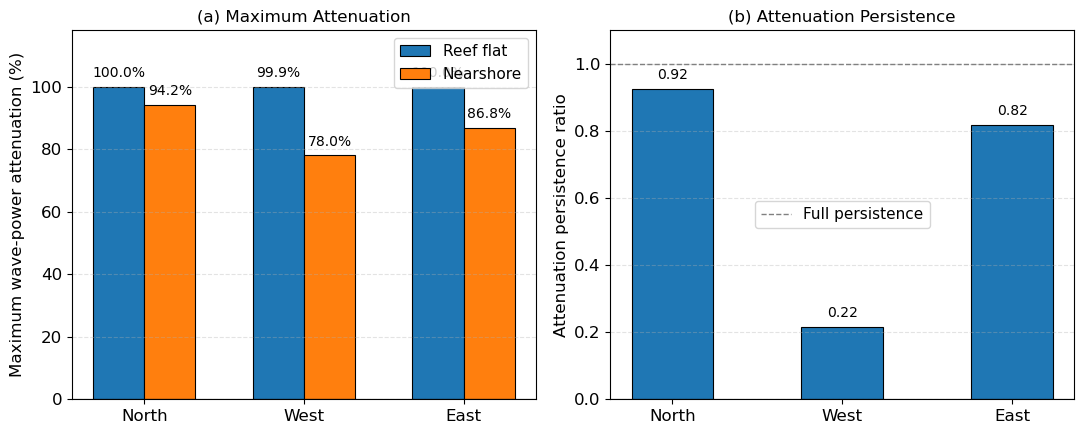


Figure saved:
D:\Phd Research\Wave Model\small scale port lavaca\Simulation\wave_power_attenuation_and_persistence.png


In [24]:
import mikeio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==========================================================
# File paths
# ==========================================================

dfsu_no_reef = (
    r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
    r"\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files"
    r"\small_scale_wave_result.dfsu"
)

reef_cases = {
    "North": {
        "file": (
            r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
            r"\Northside_barrier_reef_1.5m_v3.sw - Result Files"
            r"\Northside_barrier_reef_1.5m_v3.dfsu"
        ),
        "points": {
            "Nearshore": (732244, 3178728),
            "Reef Flat": (732448, 3178266),
        },
    },

    "West": {
        "file": (
            r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
            r"\West_side_barrier_reef_1.5m_v2.sw - Result Files"
            r"\west_side_barrier_reef_1.5m_v2.dfsu"
        ),
        "points": {
            "Nearshore": (730601, 3174580),
            "Reef Flat": (730961, 3174951),
        },
    },

    "East": {
        "file": (
            r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
            r"\east_side_barrier_reef_1.5m_v2.sw - Result Files"
            r"\east_side_reef_1.5m_v2.dfsu"
        ),
        "points": {
            "Nearshore": (736397, 3177672),
            "Reef Flat": (735938, 3177515),
        },
    },
}

# ==========================================================
# Output paths
# ==========================================================

output_folder = Path(
    r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
)

excel_out = output_folder / "wave_power_attenuation_summary.xlsx"
figure_out = output_folder / "wave_power_attenuation_and_persistence.png"

item_name = "Wave power, p"

# Avoid division by zero or nearly zero no-reef wave power
minimum_wave_power = 1.0e-8

# ==========================================================
# Time range
# ==========================================================

start_time = pd.Timestamp("2017-08-25 00:00:00")
end_time = pd.Timestamp("2017-08-27 00:00:00")

# ==========================================================
# Extract wave-power time series at nearest mesh elements
# ==========================================================

def extract_wave_power_at_points(dfsu_path, target_points):
    """
    Extract Wave power, p time series at the nearest mesh element
    for each target coordinate.
    """

    dfs = mikeio.open(dfsu_path)
    ds = dfs.read(items=[item_name])
    da = ds[0]

    element_coords = np.asarray(
        dfs.geometry.element_coordinates
    )[:, :2]

    time_index = pd.to_datetime(ds.time)

    df = pd.DataFrame(index=time_index)
    df.index.name = "Time"

    point_records = []

    for point_name, (x_target, y_target) in target_points.items():

        distances = np.sqrt(
            (element_coords[:, 0] - x_target) ** 2
            + (element_coords[:, 1] - y_target) ** 2
        )

        nearest_element = int(np.argmin(distances))

        values = np.asarray(
            da.values[:, nearest_element],
            dtype=float
        )

        # Replace MIKE delete values with NaN
        values[np.abs(values) > 1.0e30] = np.nan

        df[point_name] = values

        point_records.append({
            "Point": point_name,
            "Requested_Easting_m": x_target,
            "Requested_Northing_m": y_target,
            "Nearest_Element_ID_Zero_Based": nearest_element,
            "Actual_Easting_m": element_coords[nearest_element, 0],
            "Actual_Northing_m": element_coords[nearest_element, 1],
            "Distance_to_Nearest_Element_m": distances[nearest_element],
        })

    point_info = pd.DataFrame(point_records)

    return df, point_info

# ==========================================================
# Calculate percentage reduction
# ==========================================================

def calculate_reduction(no_reef_series, reef_series):
    """
    Calculate:

    Delta P = (P_no reef - P_reef) / P_no reef * 100
    """

    combined = pd.concat(
        [
            no_reef_series.rename("No_Reef"),
            reef_series.rename("With_Reef"),
        ],
        axis=1,
        join="inner"
    )

    # Restrict calculation to selected time range
    combined = combined.loc[
        (combined.index >= start_time)
        & (combined.index <= end_time)
    ].copy()

    valid = (
        combined["No_Reef"].notna()
        & combined["With_Reef"].notna()
        & (combined["No_Reef"].abs() > minimum_wave_power)
    )

    combined["Reduction_Percent"] = np.nan

    combined.loc[valid, "Reduction_Percent"] = (
        (
            combined.loc[valid, "No_Reef"]
            - combined.loc[valid, "With_Reef"]
        )
        / combined.loc[valid, "No_Reef"]
        * 100.0
    )

    return combined

# ==========================================================
# Extract data and calculate time-dependent attenuation
# ==========================================================

reduction_results = {}
point_information = {}

for side_name, case in reef_cases.items():

    print(f"Processing {side_name} reef...")

    # Reef-condition time series
    reef_df, reef_point_info = extract_wave_power_at_points(
        case["file"],
        case["points"]
    )

    # Corresponding no-reef time series at the same coordinates
    no_reef_df, no_reef_point_info = extract_wave_power_at_points(
        dfsu_no_reef,
        case["points"]
    )

    point_information[f"{side_name}_Reef"] = reef_point_info
    point_information[f"{side_name}_No_Reef"] = no_reef_point_info

    reduction_results[side_name] = {}

    for location in ["Reef Flat", "Nearshore"]:

        reduction_results[side_name][location] = calculate_reduction(
            no_reef_df[location],
            reef_df[location]
        )

# ==========================================================
# Calculate maximum attenuation and attenuation persistence
# ==========================================================

summary_records = []

for side_name in ["North", "West", "East"]:

    reef_flat_series = reduction_results[side_name]["Reef Flat"][
        "Reduction_Percent"
    ]

    nearshore_series = reduction_results[side_name]["Nearshore"][
        "Reduction_Percent"
    ]

    # Remove NaN values before determining maxima
    valid_reef_flat = reef_flat_series.dropna()
    valid_nearshore = nearshore_series.dropna()

    if valid_reef_flat.empty:

        reef_flat_max = np.nan
        reef_flat_max_time = pd.NaT
        nearshore_at_reef_flat_max = np.nan
        persistence_ratio = np.nan

    else:

        # Maximum reef-flat attenuation
        reef_flat_max = valid_reef_flat.max()
        reef_flat_max_time = valid_reef_flat.idxmax()

        # Nearshore attenuation at exactly the same time
        if reef_flat_max_time in nearshore_series.index:
            nearshore_at_reef_flat_max = nearshore_series.loc[
                reef_flat_max_time
            ]
        else:
            nearshore_at_reef_flat_max = np.nan

        # Persistence ratio
        if (
            np.isfinite(reef_flat_max)
            and np.isfinite(nearshore_at_reef_flat_max)
            and abs(reef_flat_max) > 1.0e-12
        ):
            persistence_ratio = (
                nearshore_at_reef_flat_max
                / reef_flat_max
            )
        else:
            persistence_ratio = np.nan

    # Independent maximum nearshore attenuation
    if valid_nearshore.empty:
        nearshore_max = np.nan
        nearshore_max_time = pd.NaT
    else:
        nearshore_max = valid_nearshore.max()
        nearshore_max_time = valid_nearshore.idxmax()

    summary_records.append({
        "Location": side_name,
        "Maximum_Reef_Flat_Attenuation_Percent": reef_flat_max,
        "Time_of_Maximum_Reef_Flat_Attenuation": reef_flat_max_time,
        "Maximum_Nearshore_Attenuation_Percent": nearshore_max,
        "Time_of_Maximum_Nearshore_Attenuation": nearshore_max_time,
        "Nearshore_Attenuation_at_Reef_Flat_Max_Percent":
            nearshore_at_reef_flat_max,
        "Attenuation_Persistence_Ratio": persistence_ratio,
        "Attenuation_Persistence_Percent":
            persistence_ratio * 100.0
            if np.isfinite(persistence_ratio)
            else np.nan,
    })

summary_df = pd.DataFrame(summary_records)

print("\nAttenuation summary:")
print(summary_df.to_string(index=False))

# ==========================================================
# Export results to Excel
# ==========================================================

with pd.ExcelWriter(excel_out, engine="openpyxl") as writer:

    summary_df.to_excel(
        writer,
        sheet_name="Attenuation_Summary",
        index=False
    )

    for location in ["Reef Flat", "Nearshore"]:

        combined_df = pd.DataFrame()

        for side_name in ["North", "West", "East"]:

            comparison = reduction_results[side_name][location]

            combined_df[
                f"{side_name}_No_Reef_Wave_Power"
            ] = comparison["No_Reef"]

            combined_df[
                f"{side_name}_With_Reef_Wave_Power"
            ] = comparison["With_Reef"]

            combined_df[
                f"{side_name}_Reduction_Percent"
            ] = comparison["Reduction_Percent"]

        sheet_name = location.replace(" ", "_")

        combined_df.to_excel(
            writer,
            sheet_name=sheet_name,
            index=True
        )

    for sheet_name, info_df in point_information.items():

        info_df.to_excel(
            writer,
            sheet_name=sheet_name[:31],
            index=False
        )

print("\nExcel output saved:")
print(excel_out)

# ==========================================================
# Prepare plotting data
# ==========================================================

locations = summary_df["Location"].tolist()

reef_flat_max_values = summary_df[
    "Maximum_Reef_Flat_Attenuation_Percent"
].to_numpy()

nearshore_max_values = summary_df[
    "Maximum_Nearshore_Attenuation_Percent"
].to_numpy()

persistence_values = summary_df[
    "Attenuation_Persistence_Ratio"
].to_numpy()

# ==========================================================
# Plot settings
# ==========================================================

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
})

fig, (ax_max, ax_persistence) = plt.subplots(
    1,
    2,
    figsize=(11, 4.5)
)

x = np.arange(len(locations))
bar_width = 0.32

# ==========================================================
# Panel (a): Maximum attenuation
# ==========================================================

bars_reef_flat = ax_max.bar(
    x - bar_width / 2,
    reef_flat_max_values,
    width=bar_width,
    label="Reef flat",
    edgecolor="black",
    linewidth=0.8
)

bars_nearshore = ax_max.bar(
    x + bar_width / 2,
    nearshore_max_values,
    width=bar_width,
    label="Nearshore",
    edgecolor="black",
    linewidth=0.8
)

ax_max.set_xticks(x)
ax_max.set_xticklabels(locations)

ax_max.set_ylabel("Maximum wave-power attenuation (%)")
ax_max.set_title("(a) Maximum Attenuation")
ax_max.axhline(0, color="black", linewidth=0.8)
ax_max.grid(axis="y", linestyle="--", alpha=0.35)
ax_max.legend(frameon=True)

# ==========================================================
# Panel (b): Attenuation persistence
# ==========================================================

bars_persistence = ax_persistence.bar(
    x,
    persistence_values,
    width=0.48,
    edgecolor="black",
    linewidth=0.8
)

ax_persistence.set_xticks(x)
ax_persistence.set_xticklabels(locations)

ax_persistence.set_ylabel("Attenuation persistence ratio")
ax_persistence.set_title("(b) Attenuation Persistence")
ax_persistence.axhline(0, color="black", linewidth=0.8)
ax_persistence.axhline(
    1,
    color="gray",
    linestyle="--",
    linewidth=1.0,
    label="Full persistence"
)
ax_persistence.grid(axis="y", linestyle="--", alpha=0.35)
ax_persistence.legend(frameon=True)

# ==========================================================
# Add bar labels
# ==========================================================

def add_percent_labels(ax, bars):

    y_min, y_max = ax.get_ylim()
    offset = 0.02 * (y_max - y_min)

    for bar in bars:

        value = bar.get_height()

        if np.isfinite(value):

            vertical_alignment = "bottom" if value >= 0 else "top"
            label_y = value + offset if value >= 0 else value - offset

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                label_y,
                f"{value:.1f}%",
                ha="center",
                va=vertical_alignment,
                fontsize=10
            )

def add_ratio_labels(ax, bars):

    y_min, y_max = ax.get_ylim()
    offset = 0.02 * (y_max - y_min)

    for bar in bars:

        value = bar.get_height()

        if np.isfinite(value):

            vertical_alignment = "bottom" if value >= 0 else "top"
            label_y = value + offset if value >= 0 else value - offset

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                label_y,
                f"{value:.2f}",
                ha="center",
                va=vertical_alignment,
                fontsize=10
            )

# Establish temporary axis limits before calculating offsets
ax_max.relim()
ax_max.autoscale_view()

ax_persistence.relim()
ax_persistence.autoscale_view()

add_percent_labels(ax_max, bars_reef_flat)
add_percent_labels(ax_max, bars_nearshore)
add_ratio_labels(ax_persistence, bars_persistence)

# Add space above bars
max_att_value = np.nanmax(
    np.concatenate([
        reef_flat_max_values,
        nearshore_max_values
    ])
)

if np.isfinite(max_att_value):
    ax_max.set_ylim(
        min(0, np.nanmin([
            reef_flat_max_values,
            nearshore_max_values
        ])),
        max_att_value * 1.18
    )

max_persistence = np.nanmax(persistence_values)

if np.isfinite(max_persistence):
    ax_persistence.set_ylim(
        min(0, np.nanmin(persistence_values)),
        max(1.1, max_persistence * 1.18)
    )

plt.tight_layout()

plt.savefig(
    figure_out,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved:")
print(figure_out)


PROCESSING NORTH
Number of extraction points: 250
Actual coordinate-based transect length: 1500.20 m
Assigned analysis distance: 0–1500 m

----------------------------------------------------------------------
Location: North
Condition: With Reef
File: D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Northside_barrier_reef_1.5m_v3.sw - Result Files\Northside_barrier_reef_1.5m_v3.dfsu
----------------------------------------------------------------------
Selected item: Wave power, p
Selected time range: 2017-08-25 00:00:00 to 2017-08-27 00:00:00
Selected timesteps: 97

----------------------------------------------------------------------
Location: North
Condition: No Reef
File: D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu
----------------------------------------------------------------------
Selected item: Wave power, p
Selected time range: 2017-08-25 00:00:00 to 2017-08-

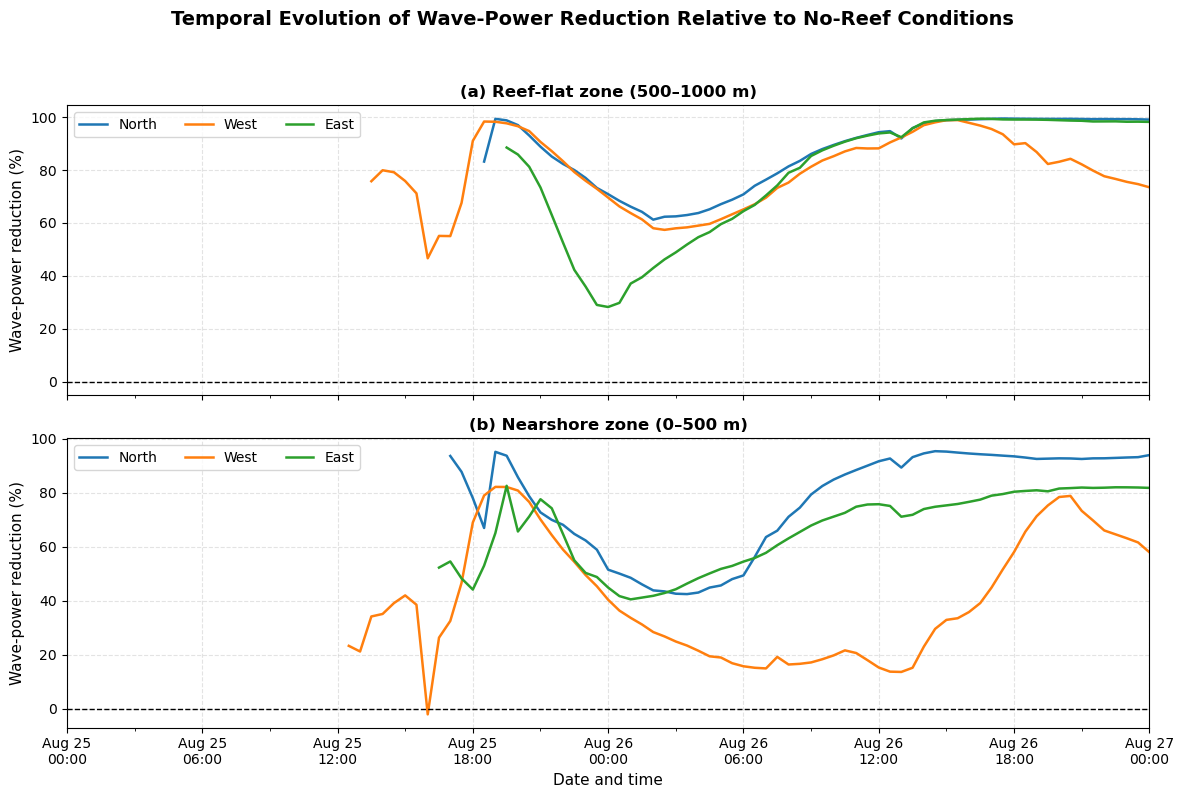

Figure saved to:
D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Temporal_wave_power_reduction_20170825_to_20170827.png

REEF-FLAT WAVE-POWER REDUCTION (%)
       count       mean        std        min        25%        50%  \
North   60.0  86.729025  13.411730  61.227658  75.778595  92.031766   
West    70.0  79.250306  13.635054  46.635976  69.556674  79.841175   
East    58.0  78.127272  23.390651  28.222180  60.038647  88.828444   

             75%        max  
North  99.169224  99.467041  
West   90.357208  98.866548  
East   98.378277  99.388555  

NEARSHORE WAVE-POWER REDUCTION (%)
       count       mean        std        min        25%        50%  \
North   63.0  76.952184  19.023096  42.431696  62.924374  86.705900   
West    72.0  40.480994  22.681354  -2.087489  20.401300  34.617206   
East    64.0  65.718032  14.099250  40.482010  52.713605  71.094080   

             75%        max  
North  92.991432  95.337488  
West   61.944947  82.121637  
East   77.8867

In [26]:
import mikeio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# ============================================================
# USER SETTINGS
# ============================================================

item_name = "Wave power, p"

# Number of extraction points along each transect
n_points = 250

# Assigned transect length
transect_distance_m = 1500.0

# Spatial zones measured from the first transect coordinate
nearshore_start = 0.0
nearshore_end = 500.0

reef_flat_start = 500.0
reef_flat_end = 1000.0

# Avoid unstable percentage values when no-reef power is near zero
denominator_tolerance = 1.0e-8

# ============================================================
# DEFINE TIME RANGE
# ============================================================

start_time = np.datetime64("2017-08-25T00:00")
end_time = np.datetime64("2017-08-27T00:00")

# Pandas timestamps used for filtering and plotting
start_timestamp = pd.Timestamp(start_time)
end_timestamp = pd.Timestamp(end_time)

# ============================================================
# NO-REEF DFSU FILE
# ============================================================

dfsu_no_reef = (
    r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
    r"\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files"
    r"\small_scale_wave_result.dfsu"
)

# ============================================================
# REEF FILES AND TRANSECTS
#
# The first coordinate is assigned distance = 0 m.
# The second coordinate is assigned distance = 1500 m.
#
# Therefore, the first coordinate should represent the
# nearshore end of each transect.
# ============================================================

configurations = {
    "North": {
        "reef_file": (
            r"D:\Phd Research\Wave Model\small scale port lavaca"
            r"\Simulation\Northside_barrier_reef_1.5m_v3.sw - Result Files"
            r"\Northside_barrier_reef_1.5m_v3.dfsu"
        ),
        "start": (732144.0, 3178938.0),
        "end": (732762.0, 3177571.0),
    },

    "West": {
        "reef_file": (
            r"D:\Phd Research\Wave Model\small scale port lavaca"
            r"\Simulation\West_side_barrier_reef_1.5m_v2.sw - Result Files"
            r"\west_side_barrier_reef_1.5m_v2.dfsu"
        ),
        "start": (730446.0, 3174401.0),
        "end": (731495.0, 3175473.0),
    },

    "East": {
        "reef_file": (
            r"D:\Phd Research\Wave Model\small scale port lavaca"
            r"\Simulation\east_side_barrier_reef_1.5m_v2.sw - Result Files"
            r"\east_side_reef_1.5m_v2.dfsu"
        ),
        "start": (736662.0, 3177738.0),
        "end": (735243.0, 3177252.0),
    },
}

# ============================================================
# OUTPUT FILES
# ============================================================

output_directory = Path(
    r"D:\Phd Research\Wave Model\small scale port lavaca"
    r"\Simulation"
)

output_excel = output_directory / (
    "Temporal_wave_power_reduction_20170825_to_20170827.xlsx"
)

output_figure = output_directory / (
    "Temporal_wave_power_reduction_20170825_to_20170827.png"
)

# ============================================================
# FUNCTION: CREATE TRANSECT POINTS
# ============================================================

def create_transect_points(
    start_xy,
    end_xy,
    number_of_points,
    assigned_length
):
    """
    Create equally spaced XY extraction points along a straight
    transect.

    Parameters
    ----------
    start_xy : tuple
        Starting X and Y coordinates.
    end_xy : tuple
        Ending X and Y coordinates.
    number_of_points : int
        Number of extraction points.
    assigned_length : float
        Assigned profile length in meters.

    Returns
    -------
    xy : ndarray
        Extraction coordinates with shape (number_of_points, 2).
    distance : ndarray
        Distance from 0 to assigned_length.
    actual_length : float
        Straight-line coordinate distance between endpoints.
    """
    x0, y0 = start_xy
    x1, y1 = end_xy

    x = np.linspace(x0, x1, number_of_points)
    y = np.linspace(y0, y1, number_of_points)

    xy = np.column_stack((x, y))

    distance = np.linspace(
        0.0,
        assigned_length,
        number_of_points
    )

    actual_length = np.hypot(
        x1 - x0,
        y1 - y0
    )

    return xy, distance, actual_length


# ============================================================
# FUNCTION: FIND WAVE-POWER ITEM
# ============================================================

def find_wave_power_item(dfs, requested_name):
    """
    Identify the wave-power item in the DFSU file.

    The function first attempts an exact case-insensitive match.
    If no exact match is found, it searches for an item containing
    both 'wave' and 'power'.
    """
    available_names = [
        item.name for item in dfs.items
    ]

    # Exact case-insensitive match
    for name in available_names:
        if name.strip().lower() == requested_name.strip().lower():
            return name

    # Partial match
    candidates = [
        name
        for name in available_names
        if (
            "wave" in name.lower()
            and "power" in name.lower()
        )
    ]

    if len(candidates) == 1:
        print(
            f"Exact item '{requested_name}' was not found. "
            f"Using '{candidates[0]}'."
        )
        return candidates[0]

    raise ValueError(
        f"Could not uniquely identify '{requested_name}'.\n"
        f"Available items are:\n{available_names}"
    )


# ============================================================
# FUNCTION: STANDARDIZE INTERPOLATION OUTPUT
# ============================================================

def convert_to_time_point_array(
    values,
    n_times,
    n_profile_points
):
    """
    Convert the interpolation result to the standard format:

        rows    = timesteps
        columns = extraction points

    Output shape:
        (n_times, n_profile_points)
    """
    values = np.asarray(values)
    values = np.squeeze(values)

    if values.ndim == 1:

        if (
            n_times == 1
            and values.size == n_profile_points
        ):
            return values.reshape(
                1,
                n_profile_points
            )

        if (
            n_profile_points == 1
            and values.size == n_times
        ):
            return values.reshape(
                n_times,
                1
            )

        raise ValueError(
            "Unexpected one-dimensional interpolation output.\n"
            f"Shape: {values.shape}"
        )

    if values.ndim != 2:
        raise ValueError(
            "Unexpected interpolation output dimensions.\n"
            f"Shape: {values.shape}"
        )

    # Expected arrangement
    if values.shape == (
        n_times,
        n_profile_points
    ):
        return values

    # Transposed arrangement
    if values.shape == (
        n_profile_points,
        n_times
    ):
        return values.T

    raise ValueError(
        "Could not identify the time and point dimensions.\n"
        f"Actual shape: {values.shape}\n"
        f"Expected: ({n_times}, {n_profile_points}) "
        f"or ({n_profile_points}, {n_times})"
    )


# ============================================================
# FUNCTION: EXTRACT TRANSECT TIME SERIES
# ============================================================

def extract_wave_power_at_transect(
    dfsu_path,
    xy,
    location_name,
    condition_name
):
    """
    Extract wave-power time series at all transect points and
    retain only data between start_time and end_time.
    """
    dfsu_path = Path(dfsu_path)

    if not dfsu_path.exists():
        raise FileNotFoundError(
            f"{condition_name} file for {location_name} "
            f"was not found:\n{dfsu_path}"
        )

    print("\n" + "-" * 70)
    print(f"Location: {location_name}")
    print(f"Condition: {condition_name}")
    print(f"File: {dfsu_path}")
    print("-" * 70)

    dfs = mikeio.open(
        str(dfsu_path)
    )

    selected_item = find_wave_power_item(
        dfs,
        item_name
    )

    print(f"Selected item: {selected_item}")

    # Read complete item
    dataset = dfs.read(
        items=[selected_item]
    )

    # DFSU time values
    time = pd.DatetimeIndex(
        dataset.time
    )

    # --------------------------------------------------------
    # Select only requested time period
    # --------------------------------------------------------
    time_mask = (
        (time >= start_timestamp)
        & (time <= end_timestamp)
    )

    time_indices = np.where(time_mask)[0]

    if len(time_indices) == 0:
        raise ValueError(
            f"No records were found between "
            f"{start_timestamp} and {end_timestamp} "
            f"for {location_name}, {condition_name}."
        )

    print(
        f"Selected time range: "
        f"{time[time_indices[0]]} to "
        f"{time[time_indices[-1]]}"
    )

    print(
        f"Selected timesteps: {len(time_indices)}"
    )

    # --------------------------------------------------------
    # Generate interpolation weights
    # --------------------------------------------------------
    elem_ids, weights = (
        dfs.geometry.get_2d_interpolant(xy)
    )

    # --------------------------------------------------------
    # Interpolate all timesteps to all transect points
    # --------------------------------------------------------
    interpolated = dfs.geometry.interp2d(
        dataset[0],
        elem_ids=elem_ids,
        weights=weights
    )

    wave_power = convert_to_time_point_array(
        values=interpolated,
        n_times=len(time),
        n_profile_points=len(xy)
    )

    wave_power = wave_power.astype(float)

    # Replace extreme MIKE delete values with NaN
    wave_power[
        np.abs(wave_power) > 1.0e30
    ] = np.nan

    # --------------------------------------------------------
    # Apply temporal selection
    # --------------------------------------------------------
    selected_time = time[time_indices]

    selected_wave_power = wave_power[
        time_indices,
        :
    ]

    point_columns = [
        f"P{i + 1:03d}"
        for i in range(len(xy))
    ]

    result = pd.DataFrame(
        selected_wave_power,
        index=selected_time,
        columns=point_columns
    )

    result.index.name = "Time"

    return result


# ============================================================
# FUNCTION: CALCULATE ZONE-AVERAGED WAVE POWER
# ============================================================

def calculate_zone_average(
    point_timeseries,
    distance,
    zone_start,
    zone_end,
    include_right_boundary=True
):
    """
    Calculate spatially averaged wave power for every timestep
    within a selected transect zone.
    """
    if include_right_boundary:
        zone_mask = (
            (distance >= zone_start)
            & (distance <= zone_end)
        )
    else:
        zone_mask = (
            (distance >= zone_start)
            & (distance < zone_end)
        )

    if not np.any(zone_mask):
        raise ValueError(
            f"No extraction points were selected between "
            f"{zone_start} and {zone_end} m."
        )

    zone_average = point_timeseries.iloc[
        :,
        zone_mask
    ].mean(
        axis=1,
        skipna=True
    )

    return zone_average, zone_mask


# ============================================================
# FUNCTION: CALCULATE PERCENTAGE REDUCTION
# ============================================================

def calculate_percent_reduction(
    no_reef,
    with_reef,
    tolerance
):
    """
    Calculate temporal wave-power reduction:

              P_no-reef - P_with-reef
    Delta P = ------------------------ x 100
                    P_no-reef

    No-reef values close to zero are assigned NaN.
    """
    common_time = no_reef.index.intersection(
        with_reef.index
    )

    if len(common_time) == 0:
        raise ValueError(
            "The reef and no-reef simulations have "
            "no common timestamps."
        )

    no_reef_aligned = no_reef.loc[
        common_time
    ].astype(float)

    with_reef_aligned = with_reef.loc[
        common_time
    ].astype(float)

    valid_denominator = (
        np.abs(no_reef_aligned) > tolerance
    )

    reduction = pd.Series(
        data=np.nan,
        index=common_time,
        dtype=float
    )

    reduction.loc[valid_denominator] = (
        (
            no_reef_aligned.loc[valid_denominator]
            - with_reef_aligned.loc[valid_denominator]
        )
        / no_reef_aligned.loc[valid_denominator]
    ) * 100.0

    reduction.index.name = "Time"

    return (
        reduction,
        no_reef_aligned,
        with_reef_aligned
    )


# ============================================================
# PROCESS NORTH, WEST, AND EAST
# ============================================================

results = {}

for location, settings in configurations.items():

    print("\n" + "=" * 75)
    print(f"PROCESSING {location.upper()}")
    print("=" * 75)

    # --------------------------------------------------------
    # Create identical transect points for reef and no-reef
    # --------------------------------------------------------
    xy, distance, actual_length = create_transect_points(
        start_xy=settings["start"],
        end_xy=settings["end"],
        number_of_points=n_points,
        assigned_length=transect_distance_m
    )

    print(
        f"Number of extraction points: {n_points}"
    )

    print(
        f"Actual coordinate-based transect length: "
        f"{actual_length:.2f} m"
    )

    print(
        f"Assigned analysis distance: "
        f"0–{transect_distance_m:.0f} m"
    )

    # --------------------------------------------------------
    # Extract with-reef condition
    # --------------------------------------------------------
    reef_points = extract_wave_power_at_transect(
        dfsu_path=settings["reef_file"],
        xy=xy,
        location_name=location,
        condition_name="With Reef"
    )

    # --------------------------------------------------------
    # Extract corresponding no-reef condition
    # --------------------------------------------------------
    no_reef_points = extract_wave_power_at_transect(
        dfsu_path=dfsu_no_reef,
        xy=xy,
        location_name=location,
        condition_name="No Reef"
    )

    # --------------------------------------------------------
    # Nearshore averages
    #
    # 0 <= distance < 500 m
    # --------------------------------------------------------
    reef_nearshore, nearshore_mask = (
        calculate_zone_average(
            point_timeseries=reef_points,
            distance=distance,
            zone_start=nearshore_start,
            zone_end=nearshore_end,
            include_right_boundary=False
        )
    )

    no_reef_nearshore, _ = (
        calculate_zone_average(
            point_timeseries=no_reef_points,
            distance=distance,
            zone_start=nearshore_start,
            zone_end=nearshore_end,
            include_right_boundary=False
        )
    )

    # --------------------------------------------------------
    # Reef-flat averages
    #
    # 500 <= distance <= 1000 m
    # --------------------------------------------------------
    reef_reef_flat, reef_flat_mask = (
        calculate_zone_average(
            point_timeseries=reef_points,
            distance=distance,
            zone_start=reef_flat_start,
            zone_end=reef_flat_end,
            include_right_boundary=True
        )
    )

    no_reef_reef_flat, _ = (
        calculate_zone_average(
            point_timeseries=no_reef_points,
            distance=distance,
            zone_start=reef_flat_start,
            zone_end=reef_flat_end,
            include_right_boundary=True
        )
    )

    print(
        f"Nearshore extraction points: "
        f"{nearshore_mask.sum()}"
    )

    print(
        f"Reef-flat extraction points: "
        f"{reef_flat_mask.sum()}"
    )

    # --------------------------------------------------------
    # Calculate temporal percentage reduction
    # --------------------------------------------------------
    (
        nearshore_reduction,
        no_nearshore_aligned,
        reef_nearshore_aligned
    ) = calculate_percent_reduction(
        no_reef=no_reef_nearshore,
        with_reef=reef_nearshore,
        tolerance=denominator_tolerance
    )

    (
        reef_flat_reduction,
        no_reef_flat_aligned,
        reef_reef_flat_aligned
    ) = calculate_percent_reduction(
        no_reef=no_reef_reef_flat,
        with_reef=reef_reef_flat,
        tolerance=denominator_tolerance
    )

    # --------------------------------------------------------
    # Combined zone results
    # --------------------------------------------------------
    zone_wave_power = pd.DataFrame(
        {
            "No_Reef_Nearshore":
                no_nearshore_aligned,

            "With_Reef_Nearshore":
                reef_nearshore_aligned,

            "Nearshore_Reduction_Percent":
                nearshore_reduction,

            "No_Reef_Reef_Flat":
                no_reef_flat_aligned,

            "With_Reef_Reef_Flat":
                reef_reef_flat_aligned,

            "Reef_Flat_Reduction_Percent":
                reef_flat_reduction,
        }
    )

    zone_wave_power.index.name = "Time"

    # --------------------------------------------------------
    # Point information
    # --------------------------------------------------------
    point_information = pd.DataFrame(
        {
            "Point": np.arange(
                1,
                n_points + 1
            ),

            "Distance_m": distance,

            "X": xy[:, 0],

            "Y": xy[:, 1],

            "Zone": np.select(
                [
                    nearshore_mask,
                    reef_flat_mask
                ],
                [
                    "Nearshore",
                    "Reef Flat"
                ],
                default="Offshore"
            )
        }
    )

    results[location] = {
        "zone_wave_power":
            zone_wave_power,

        "nearshore_reduction":
            nearshore_reduction,

        "reef_flat_reduction":
            reef_flat_reduction,

        "point_information":
            point_information,

        "reef_points":
            reef_points,

        "no_reef_points":
            no_reef_points,
    }


# ============================================================
# FIND COMMON TIME PERIOD FOR NORTH, WEST, AND EAST
# ============================================================

common_time = None

for location in configurations:

    location_time = results[
        location
    ]["zone_wave_power"].index

    if common_time is None:
        common_time = location_time
    else:
        common_time = common_time.intersection(
            location_time
        )

if common_time is None or len(common_time) == 0:
    raise ValueError(
        "North, West, and East have no common timestamps "
        "within the selected time range."
    )

# Enforce requested temporal limits again
common_time = common_time[
    (common_time >= start_timestamp)
    & (common_time <= end_timestamp)
]

if len(common_time) == 0:
    raise ValueError(
        "No common timestamps remain after applying "
        "the requested time limits."
    )

print("\n" + "=" * 75)
print("COMMON ANALYSIS PERIOD")
print("=" * 75)

print(f"Start: {common_time[0]}")
print(f"End:   {common_time[-1]}")
print(f"Number of timesteps: {len(common_time)}")


# ============================================================
# CREATE COMBINED REDUCTION DATAFRAMES
# ============================================================

reef_flat_reduction_df = pd.DataFrame(
    {
        location: results[
            location
        ]["reef_flat_reduction"].reindex(
            common_time
        )
        for location in configurations
    },
    index=common_time
)

nearshore_reduction_df = pd.DataFrame(
    {
        location: results[
            location
        ]["nearshore_reduction"].reindex(
            common_time
        )
        for location in configurations
    },
    index=common_time
)

reef_flat_reduction_df.index.name = "Time"
nearshore_reduction_df.index.name = "Time"


# ============================================================
# SAVE RESULTS TO EXCEL
# ============================================================

output_directory.mkdir(
    parents=True,
    exist_ok=True
)

with pd.ExcelWriter(
    output_excel,
    engine="openpyxl"
) as writer:

    # Combined percentage-reduction results
    reef_flat_reduction_df.to_excel(
        writer,
        sheet_name="Reef_Flat_Reduction"
    )

    nearshore_reduction_df.to_excel(
        writer,
        sheet_name="Nearshore_Reduction"
    )

    # Individual location results
    for location in configurations:

        location_results = results[location]

        location_results[
            "zone_wave_power"
        ].loc[
            start_timestamp:end_timestamp
        ].to_excel(
            writer,
            sheet_name=f"{location}_Zone_Results"
        )

        location_results[
            "point_information"
        ].to_excel(
            writer,
            sheet_name=f"{location}_Points",
            index=False
        )

        location_results[
            "reef_points"
        ].loc[
            start_timestamp:end_timestamp
        ].to_excel(
            writer,
            sheet_name=f"{location}_Reef_AllPts"
        )

        location_results[
            "no_reef_points"
        ].loc[
            start_timestamp:end_timestamp
        ].to_excel(
            writer,
            sheet_name=f"{location}_NoReef_AllPts"
        )

print(
    f"\nExcel file saved to:\n{output_excel}"
)


# ============================================================
# CREATE TWO-PANEL TEMPORAL REDUCTION FIGURE
# ============================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 8),
    sharex=True
)

# ------------------------------------------------------------
# Panel (a): Reef-flat zone
# ------------------------------------------------------------
for location in configurations:

    axes[0].plot(
        reef_flat_reduction_df.index,
        reef_flat_reduction_df[location],
        linewidth=1.8,
        label=location
    )

# Zero-reduction reference line
axes[0].axhline(
    y=0.0,
    linewidth=1.0,
    linestyle="--",
    color="black"
)

# Explicit x-axis limits
axes[0].set_xlim(
    start_timestamp,
    end_timestamp
)

axes[0].set_ylabel(
    "Wave-power reduction (%)",
    fontsize=11
)

axes[0].set_title(
    "(a) Reef-flat zone (500–1000 m)",
    fontsize=12,
    fontweight="bold"
)

axes[0].grid(
    True,
    linestyle="--",
    alpha=0.35
)

axes[0].legend(
    loc="best",
    ncol=3,
    frameon=True,
    fontsize=10
)

axes[0].tick_params(
    axis="both",
    labelsize=10
)

# ------------------------------------------------------------
# Panel (b): Nearshore zone
# ------------------------------------------------------------
for location in configurations:

    axes[1].plot(
        nearshore_reduction_df.index,
        nearshore_reduction_df[location],
        linewidth=1.8,
        label=location
    )

# Zero-reduction reference line
axes[1].axhline(
    y=0.0,
    linewidth=1.0,
    linestyle="--",
    color="black"
)

# Explicit x-axis limits
axes[1].set_xlim(
    start_timestamp,
    end_timestamp
)

axes[1].set_xlabel(
    "Date and time",
    fontsize=11
)

axes[1].set_ylabel(
    "Wave-power reduction (%)",
    fontsize=11
)

axes[1].set_title(
    "(b) Nearshore zone (0–500 m)",
    fontsize=12,
    fontweight="bold"
)

axes[1].grid(
    True,
    linestyle="--",
    alpha=0.35
)

axes[1].legend(
    loc="best",
    ncol=3,
    frameon=True,
    fontsize=10
)

axes[1].tick_params(
    axis="both",
    labelsize=10
)

# ============================================================
# FORMAT DATE AXIS
# ============================================================

# Major tick every 6 hours
axes[1].xaxis.set_major_locator(
    mdates.HourLocator(
        interval=6
    )
)

axes[1].xaxis.set_major_formatter(
    mdates.DateFormatter(
        "%b %d\n%H:%M"
    )
)

# Minor tick every 3 hours
axes[1].xaxis.set_minor_locator(
    mdates.HourLocator(
        interval=3
    )
)

fig.suptitle(
    "Temporal Evolution of Wave-Power Reduction "
    "Relative to No-Reef Conditions",
    fontsize=14,
    fontweight="bold",
    y=0.995
)

plt.tight_layout(
    rect=[0, 0, 1, 0.97]
)

# ============================================================
# SAVE FIGURE
# ============================================================

plt.savefig(
    output_figure,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print(
    f"Figure saved to:\n{output_figure}"
)


# ============================================================
# SUMMARY STATISTICS FOR SELECTED PERIOD
# ============================================================

print("\n" + "=" * 75)
print("REEF-FLAT WAVE-POWER REDUCTION (%)")
print("=" * 75)

print(
    reef_flat_reduction_df.describe().T
)

print("\n" + "=" * 75)
print("NEARSHORE WAVE-POWER REDUCTION (%)")
print("=" * 75)

print(
    nearshore_reduction_df.describe().T
)